## DS 3026 Final Project - Section 2
# Part 2: Likelihood and MLE

**Inferential Question:** Does the home team have an advantage in NBA games? If it exists, has the home-court advantage changed in the modern era (post-2018)?

**Parameter of Interest**: π = true home-win probability

**Estimator:** p̂ = (number of home wins) / (total games)

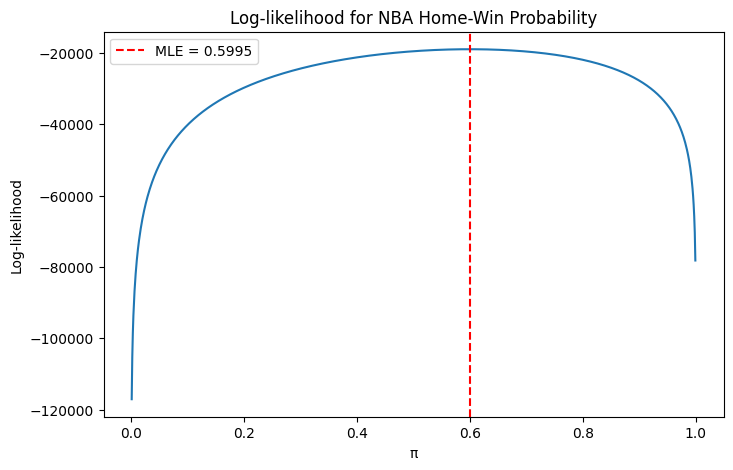

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/game_df.csv", low_memory=False)

df['home_win'] = (df['wl_home'] == 'W').astype(int)
n = len(df) # Total Games
w = df['home_win'].sum() # Home Wins
pi_hat = w / n

# Log-likelihood function
def log_likelihood(pi):
    return w * np.log(pi) + (n - w) * np.log(1 - pi)

# Grid of pi values
pi_grid = np.linspace(0.001, 0.999, 1000)
ll = log_likelihood(pi_grid)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(pi_grid, ll)
plt.axvline(pi_hat, color='red', linestyle='--', label=f'MLE = {pi_hat:.4f}')
plt.xlabel('π')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood for NBA Home-Win Probability')
plt.legend()
plt.show()